In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import sys
import os
import torch

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

In [4]:
from src.trainer import IntervalTrainer

In [ ]:
import random
from typing import List, Tuple

# Simple GridWorld environment
class GridWorld:
    def __init__(self, width=5, height=5, obstacles=None, goal=(4, 4), start=(0, 0), max_steps=50):
        self.width = width
        self.height = height
        self.obstacles = set(obstacles or {(1,1), (1,2), (2,2)})
        self.goal = goal
        self.start = start
        self.max_steps = max_steps
        self.reset()

    def reset(self):
        self.pos = self.start
        self.steps = 0
        return self._state()

    def _state(self):
        # One-hot over grid cells
        idx = self.pos[1] * self.width + self.pos[0]
        s = torch.zeros(self.width * self.height, dtype=torch.float32)
        s[idx] = 1.0
        return s

    def step(self, action: int):
        x, y = self.pos
        if action == 0:    # up
            y2 = y - 1
            x2 = x
        elif action == 1:  # down
            y2 = y + 1
            x2 = x
        elif action == 2:  # left
            x2 = x - 1
            y2 = y
        elif action == 3:  # right
            x2 = x + 1
            y2 = y
        else:
            x2, y2 = x, y

        # Boundary / obstacle check
        if not (0 <= x2 < self.width and 0 <= y2 < self.height) or (x2, y2) in self.obstacles:
            x2, y2 = x, y
            penalty = -0.1
        else:
            penalty = -0.01

        self.pos = (x2, y2)
        self.steps += 1

        done = self.pos == self.goal or self.steps >= self.max_steps
        reward = 1.0 if self.pos == self.goal else penalty
        return self._state(), reward, done

    def safe_actions_mask(self, pos):
        mask = torch.zeros(4, dtype=torch.float32)
        x, y = pos
        deltas = {0:(0,-1), 1:(0,1), 2:(-1,0), 3:(1,0)}
        for a,(dx,dy) in deltas.items():
            nx, ny = x+dx, y+dy
            if 0 <= nx < self.width and 0 <= ny < self.height and (nx, ny) not in self.obstacles:
                mask[a] = 1.0
        return mask

# Policy network
class PolicyNet(torch.nn.Module):
    def __init__(self, state_dim, hidden=64, n_actions=4):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(state_dim, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, n_actions)
        )
    def forward(self, x):
        return self.net(x)

# Instantiate environment and policy
env = GridWorld()
state_dim = env.width * env.height
n_actions = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PolicyNet(state_dim, hidden=64, n_actions=n_actions).to(device)
# Alternative approach: Define the policy as a Sequential model directly
# This would eliminate the need for the wrapper class
# sequential_policy = torch.nn.Sequential(
#     torch.nn.Linear(state_dim, 64),
#     torch.nn.ReLU(),
#     torch.nn.Linear(64, 64),
#     torch.nn.ReLU(),
#     torch.nn.Linear(64, n_actions)
# ).to(device)
# 
# # Then you could use it directly:
# # interval_trainer = IntervalTrainer(model=sequential_policy, seed=2025)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)

# REINFORCE training
def train_policy(episodes=600):
    gamma = 0.99
    for ep in range(episodes):
        log_probs: List[torch.Tensor] = []
        rewards: List[float] = []
        state = env.reset().to(device)
        done = False
        while not done:
            logits = model(state.unsqueeze(0))
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            log_probs.append(dist.log_prob(action))
            next_state, reward, done = env.step(action.item())
            rewards.append(reward)
            state = next_state.to(device)

        # Compute returns
        G = 0.0
        returns = []
        for r in reversed(rewards):
            G = r + gamma * G
            returns.append(G)
        returns.reverse()
        returns = torch.tensor(returns, dtype=torch.float32, device=device)
        if returns.std() > 1e-6:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = -(torch.stack(log_probs) * returns).sum()
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        if (ep + 1) % 100 == 0:
            avg_return = sum(rewards)
            print(f"Episode {ep+1}: return={avg_return:.2f}, loss={loss.item():.3f}")

train_policy(episodes=1_000)

# Build dataset: one sample per state with safe action mask
dataset: List[Tuple[torch.Tensor, torch.Tensor]] = []
for y in range(env.height):
    for x in range(env.width):
        if (x, y) in env.obstacles:
            continue
        idx = y * env.width + x
        s = torch.zeros(state_dim, dtype=torch.float32)
        s[idx] = 1.0
        mask = env.safe_actions_mask((x, y))
        dataset.append((s, mask))

print(f"Dataset size (states without obstacles): {len(dataset)}")

Episode 100: return=0.63, loss=-0.000
Episode 200: return=-2.03, loss=0.000
Episode 300: return=-0.83, loss=-0.000
Episode 400: return=-2.03, loss=-0.000
Episode 500: return=-2.03, loss=0.000
Episode 600: return=-0.31, loss=-0.000
Episode 700: return=0.25, loss=-0.000
Episode 800: return=-2.21, loss=-0.001
Episode 900: return=-1.05, loss=-0.000
Episode 1000: return=-1.94, loss=-0.000
Dataset size (states without obstacles): 22


In [9]:
# Compute one-step safe actions for every non-obstacle state
# Actions: 0=up, 1=down, 2=left, 3=right
action_names = ['up', 'down', 'left', 'right']
safe_actions_per_state = {}

for y in range(env.height):
    for x in range(env.width):
        if (x, y) in env.obstacles:
            continue
        m = env.safe_actions_mask((x, y))
        indices = [i for i, v in enumerate(m.tolist()) if v == 1.0]
        safe_actions_per_state[(x, y)] = {
            "indices": indices,
            "names": [action_names[i] for i in indices]
        }

# Display
for coord, info in safe_actions_per_state.items():
    print(f"State {coord}: actions {info['indices']} ({info['names']})")

State (0, 0): actions [1, 3] (['down', 'right'])
State (1, 0): actions [2, 3] (['left', 'right'])
State (2, 0): actions [1, 2, 3] (['down', 'left', 'right'])
State (3, 0): actions [1, 2, 3] (['down', 'left', 'right'])
State (4, 0): actions [1, 2] (['down', 'left'])
State (0, 1): actions [0, 1] (['up', 'down'])
State (2, 1): actions [0, 3] (['up', 'right'])
State (3, 1): actions [0, 1, 2, 3] (['up', 'down', 'left', 'right'])
State (4, 1): actions [0, 1, 2] (['up', 'down', 'left'])
State (0, 2): actions [0, 1] (['up', 'down'])
State (3, 2): actions [0, 1, 3] (['up', 'down', 'right'])
State (4, 2): actions [0, 1, 2] (['up', 'down', 'left'])
State (0, 3): actions [0, 1, 3] (['up', 'down', 'right'])
State (1, 3): actions [1, 2, 3] (['down', 'left', 'right'])
State (2, 3): actions [1, 2, 3] (['down', 'left', 'right'])
State (3, 3): actions [0, 1, 2, 3] (['up', 'down', 'left', 'right'])
State (4, 3): actions [0, 1, 2] (['up', 'down', 'left'])
State (0, 4): actions [0, 3] (['up', 'right'])
Sta

In [10]:
# Build (state, action) supervised dataset: pick one safe action per state
state_action_dataset = []
for (x, y), info in safe_actions_per_state.items():
    safe_idxs = info["indices"]
    if not safe_idxs:
        continue
    action = random.choice(safe_idxs)  # label
    idx = y * env.width + x
    s = torch.zeros(state_dim, dtype=torch.float32)
    s[idx] = 1.0
    state_action_dataset.append((s, action))

print(f"Number of samples: {len(state_action_dataset)}")
print("First 5 samples (one-hot index -> action):")
for s, a in state_action_dataset[:5]:
    print(s.argmax().item(), "->", a, action_names[a])

Number of samples: 22
First 5 samples (one-hot index -> action):
0 -> 3 right
1 -> 3 right
2 -> 2 left
3 -> 2 left
4 -> 1 down


In [12]:
from torch.utils.data import TensorDataset, DataLoader

states = torch.stack([s for s, _ in state_action_dataset])
actions = torch.tensor([a for _, a in state_action_dataset], dtype=torch.long)

state_action_torch_dataset = TensorDataset(states, actions)
state_action_loader = DataLoader(state_action_torch_dataset, batch_size=8, shuffle=True)

print(f"Dataset size: {len(state_action_torch_dataset)}")
print("States shape:", states.shape, "Actions shape:", actions.shape)

Dataset size: 22
States shape: torch.Size([22, 25]) Actions shape: torch.Size([22])


In [15]:
interval_trainer = IntervalTrainer(
    model=model.net, # policy network's Sequential part
    seed=2025,
)

interval_trainer.compute_rashomon_set(
    dataset=state_action_torch_dataset, # states and safe actions; provide one sample per state
    )

Initial acc constraint violation: -0.0497 (Positive = violated)
Number of model parameters: 6084
Computing Rashomon set with min acc limit: 0.09
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.14,  Min acc soft=0.14


100%|██████████| 2000/2000 [00:10<00:00, 182.61it/s, size=17.75, obj=0.003, min_soft_acc=0.204]


Final bbox:  Obj=0.00,  Size=17.75,  Min acc hard=0.09,  Min acc soft=0.13
Computing final certificates over 256 samples
Num cert samples: 22
----------------------- Finished Computing Rashomon set ------------------------


In [22]:
interval_trainer.bounds[0].param_l

[tensor([[-0.1978, -0.0752,  0.1286,  ..., -0.1135, -0.2015, -0.1165],
         [ 0.1321,  0.0024,  0.0687,  ...,  0.1242, -0.0986,  0.0879],
         [ 0.1506, -0.1139, -0.1916,  ..., -0.1487,  0.0104, -0.1360],
         ...,
         [-0.1669,  0.2846, -0.2201,  ...,  0.1715,  0.1226,  0.1011],
         [ 0.3203, -0.0151,  0.1299,  ..., -0.1182,  0.0212,  0.0380],
         [-0.0235, -0.1501,  0.1568,  ..., -0.1475,  0.0112, -0.1978]],
        requires_grad=True),
 tensor([ 1.6539e-01, -1.4854e-01,  7.5824e-02, -1.9087e-01, -1.9774e-01,
         -2.0364e-01,  1.1906e-01, -1.1674e-01,  7.4486e-02, -1.9062e-01,
          5.4084e-02, -1.8947e-01, -1.9545e-01, -9.1205e-02, -1.6233e-01,
         -1.9400e-01,  1.0326e-01,  6.9651e-03, -1.6945e-01,  1.0251e-01,
          1.1541e-01, -1.0531e-01, -1.7456e-01,  9.5431e-03, -1.9598e-01,
          4.4567e-02,  6.5758e-02,  1.6081e-01, -1.6636e-01,  1.1514e-01,
          9.6411e-03, -2.6173e-02, -1.7217e-01, -1.7697e-01, -7.2779e-03,
         -1.

In [23]:
interval_trainer.bounds[0].param_u

[tensor([[-0.1942, -0.0720,  0.1286,  ..., -0.1135, -0.1979, -0.1165],
         [ 0.1357,  0.0060,  0.0723,  ...,  0.1277, -0.0950,  0.0915],
         [ 0.1535, -0.1103, -0.1880,  ..., -0.1451,  0.0104, -0.1325],
         ...,
         [-0.1633,  0.2878, -0.2165,  ...,  0.1715,  0.1226,  0.1011],
         [ 0.3232, -0.0115,  0.1299,  ..., -0.1146,  0.0247,  0.0416],
         [-0.0199, -0.1465,  0.1603,  ..., -0.1439,  0.0148, -0.1942]],
        requires_grad=True),
 tensor([ 1.6539e-01, -1.4497e-01,  7.5824e-02, -1.8730e-01, -1.9417e-01,
         -2.0007e-01,  1.1906e-01, -1.1674e-01,  7.4486e-02, -1.8705e-01,
          5.4084e-02, -1.8590e-01, -1.9188e-01, -9.1205e-02, -1.6233e-01,
         -1.9043e-01,  1.0326e-01,  6.9651e-03, -1.6588e-01,  1.0251e-01,
          1.1541e-01, -1.0531e-01, -1.7456e-01,  9.5431e-03, -1.9241e-01,
          4.4567e-02,  6.5758e-02,  1.6081e-01, -1.6281e-01,  1.1514e-01,
          9.6411e-03, -2.6173e-02, -1.6860e-01, -1.7340e-01, -7.2779e-03,
         -1.

In [27]:
interval_trainer.bounds[0].param_l[0].detach()

tensor([[-0.1978, -0.0752,  0.1286,  ..., -0.1135, -0.2015, -0.1165],
        [ 0.1321,  0.0024,  0.0687,  ...,  0.1242, -0.0986,  0.0879],
        [ 0.1506, -0.1139, -0.1916,  ..., -0.1487,  0.0104, -0.1360],
        ...,
        [-0.1669,  0.2846, -0.2201,  ...,  0.1715,  0.1226,  0.1011],
        [ 0.3203, -0.0151,  0.1299,  ..., -0.1182,  0.0212,  0.0380],
        [-0.0235, -0.1501,  0.1568,  ..., -0.1475,  0.0112, -0.1978]])

In [34]:
len(interval_trainer.bounds[0].param_l)

6

In [53]:
interval_trainer.bounds[0].param_l[1].size()[0]

64

In [ ]:
if len(interval_trainer.bounds[0].param_l[0].size()) == 2: # weight matrix
    num_elems = interval_trainer.bounds[0].param_l[0].size()[0] * interval_trainer.bounds[0].param_l[0].size()[1]
else:
    num_elems = interval_trainer.bounds[0].param_l[0].size()[0]
# generate a random index
random_index = random.randint(0, num_elems - 1)


2

In [57]:
interval_trainer.bounds[0].param_l[0].detach().cpu().view(-1).size()[0]

1600

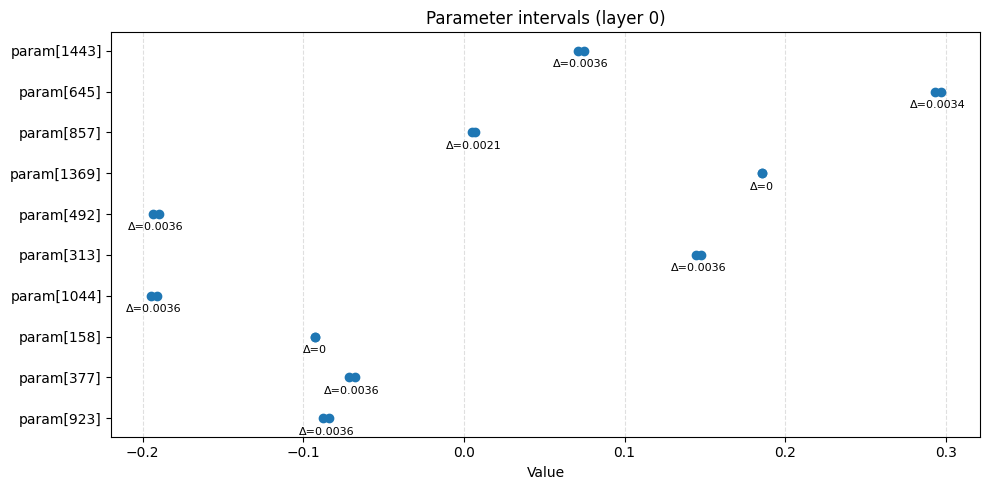

In [76]:
import matplotlib.pyplot as plt

layer_index = 0

# 3 linear layers, each has weight matrix and bias vector -> 6 elements in interval_trainer.bounds[0].param_l

# Access lower / upper bounds for first bounded parameter group
param_l = interval_trainer.bounds[0].param_l[layer_index].detach().cpu().view(-1)
param_u = interval_trainer.bounds[0].param_u[layer_index].detach().cpu().view(-1)
assert param_l.shape == param_u.shape, "Lower/upper bounds shape mismatch."

# Choose two parameter indices to visualize (change if desired)

num_elems = param_l.size()[0]
# generate 10 random indices
param_indices = random.sample(range(num_elems), 10)
intervals = []
for idx in param_indices:
    l = param_l[idx].item()
    u = param_u[idx].item()
    intervals.append((idx, l, u))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
y_positions = range(len(intervals))
for y_pos, (pidx, l, u) in zip(y_positions, intervals):
    ax.hlines(y_pos, l, u, colors='tab:blue', linewidth=3)
    ax.plot([l, u], [y_pos, y_pos], 'o', color='tab:blue')
    # ax.text(u, y_pos + 0.2, f"{u:.2g}", fontsize=8)
    # ax.text(l, y_pos + 0.2, f"{l:.2g}", fontsize=8)
    ax.text((l + u) / 2, y_pos - 0.4, f"Δ={(u - l):.2g}", ha='center', fontsize=8)

ax.set_yticks(list(y_positions))
ax.set_yticklabels([f"param[{pidx}]" for pidx, _, _ in intervals])
ax.set_xlabel("Value")
ax.set_title(f"Parameter intervals (layer {layer_index})")
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# print(intervals) # Shows the raw (index, lower, upper) tuples

In [77]:
# Compute and display 5 widest parameter intervals for the current layer (uses existing param_l, param_u)
widths = param_u - param_l
topk = torch.topk(widths, k=5)
print(f"Top 5 widest parameter intervals (layer {layer_index}):")
for rank, (idx, w) in enumerate(zip(topk.indices.tolist(), topk.values.tolist()), 1):
    l = param_l[idx].item()
    u = param_u[idx].item()
    print(f"{rank}. param[{idx}]  lower={l:.6f}  upper={u:.6f}  width={w:.6f}")

Top 5 widest parameter intervals (layer 0):
1. param[1154]  lower=0.251697  upper=0.255326  width=0.003629
2. param[504]  lower=0.263035  upper=0.266664  width=0.003629
3. param[1430]  lower=0.249929  upper=0.253556  width=0.003628
4. param[13]  lower=0.261269  upper=0.264893  width=0.003624
5. param[638]  lower=0.331389  upper=0.335013  width=0.003624
